In [274]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

seed= 42

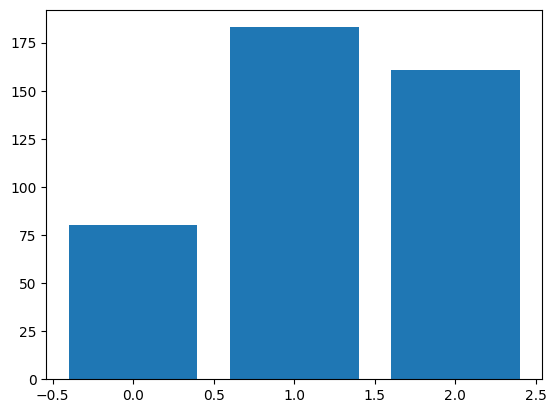

In [275]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

train_df= pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')

le= LabelEncoder()

X= train_df['text']
y= le.fit_transform(train_df['label'])

X_train, X_eval, y_train, y_eval= train_test_split(X, y, stratify= y, train_size=0.9, random_state=seed)

X_test= test_df['text']

values, counts= np.unique(y, return_counts= True)

plt.bar(values, counts)
plt.show()

In [276]:
# Subtask 1

answer1= []

answer1.append({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': train_df['text'].str.count(r'\bpâni\b', flags=re.IGNORECASE).sum() + test_df['text'].str.count(r'\bpâni\b', flags=re.IGNORECASE).sum()
})

answer1= pd.DataFrame(answer1)
answer1

,subtaskID,datapointID,answer
0,1,1,13


In [277]:
# Subtask 2

mean1= np.mean(train_df[train_df['label']== 'graiul moldovenesc']['text'].str.count(r'[^\w\s]'))

mean2= np.mean(train_df[train_df['label']== 'graiul bănățean']['text'].str.count(r'[^\w\s]'))

answer2= []

answer2.append({
    'subtaskID': 2,
    'datapointID': 1,
    'answer': round(abs(mean1-mean2), 2)
})

answer2= pd.DataFrame(answer2)
answer2

,subtaskID,datapointID,answer
0,2,1,0.05


In [278]:
# Subtask 3

diacritics= "ăâîșțĂÂÎȘȚ"

diacritics= test_df['text'].apply(lambda x: sum(1 for c in str(x) if c in diacritics))

answer3= [{
    'subtaskID': 3,
    'datapointID': id_,
    'answer': ans
} for id_, ans in zip(test_df['ID'], diacritics)]

answer3= pd.DataFrame(answer3)
answer3

,subtaskID,datapointID,answer
0,3,1491,2
1,3,1493,3
2,3,1495,3
3,3,1497,5
4,3,1499,8
...,...,...,...
102,3,1695,1
103,3,1697,2
104,3,1699,6
105,3,1701,2


In [279]:
# Subtask 4

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

features= FeatureUnion([
    ('chars', TfidfVectorizer(
        ngram_range=(2,6),
        lowercase=True,
        min_df=2,
        max_df= 0.9,
        analyzer='char_wb',
        sublinear_tf=True
    ))
])


model= Pipeline([
    ('features', features),
    ('LR', LinearSVC(
        max_iter=2000,
        random_state=42,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

y_preds= model.predict(X_eval)

print(classification_report(y_eval, y_preds))

predictions= le.inverse_transform(model.predict(X_test))

answer4= [{
    'subtaskID': 4,
    'datapointID': id_,
    'answer': ans
} for id_, ans in zip(test_df['ID'], predictions)]

answer4= pd.DataFrame(answer4)
answer4

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.83      1.00      0.90        19
           2       1.00      0.88      0.93        16

    accuracy                           0.91        43
   macro avg       0.94      0.88      0.90        43
weighted avg       0.92      0.91      0.91        43



,subtaskID,datapointID,answer
0,4,1491,graiul moldovenesc
1,4,1493,româna standard
2,4,1495,româna standard
3,4,1497,graiul moldovenesc
4,4,1499,graiul moldovenesc
...,...,...,...
102,4,1695,româna standard
103,4,1697,româna standard
104,4,1699,graiul bănățean
105,4,1701,româna standard


In [280]:
answer = pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv('submission.csv', index= False)